In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score

In [3]:
df = pd.read_csv("bank-additional.csv", sep = ";")
df.head(15)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
5,32,services,single,university.degree,no,no,no,cellular,sep,thu,...,3,999,2,failure,-1.1,94.199,-37.5,0.884,4963.6,no
6,32,admin.,single,university.degree,no,yes,no,cellular,sep,mon,...,4,999,0,nonexistent,-1.1,94.199,-37.5,0.879,4963.6,no
7,41,entrepreneur,married,university.degree,unknown,yes,no,cellular,nov,mon,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
8,31,services,divorced,professional.course,no,no,no,cellular,nov,tue,...,1,999,1,failure,-0.1,93.200,-42.0,4.153,5195.8,no
9,35,blue-collar,married,basic.9y,unknown,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no


1. Identify the target variable

The target variable for the analysis and based on the instruction should be "y" which refers to whether the client subscribed to the product after the marketing campaign contacted them, this is the whole business objective of the campaign. Other variables that could be valid targets are "campaign", which refers to the number of times the client was contacted during the campaign, and "duration" which refers to the call duration (in seconds).

However, they are not to be treated as prediction objectives because they are not aligned with the goals of the campaign. The bank (in this instance) does not want to make predictions on how many times they will call someone, they want to predict whether calling them is actually worth it. This is what the "campaign" variable refers to. Also, it can be influenced by other outside variables. What if the customer didn't answer? They might get called again in the future. When it comes to "duration", this shouldn't be treated as a target objective since in the context of the bank, they probably don't care about predicting call length, they care more about whether the customers subscribe or not. And it can also create data leakage because we can only know the call duration after it happens. The question is "Should we call this person?" and at that moment we don't know the duration. If we were to use duration, we would be modelling something that happens after the decision.


2. Data loading and exploration

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

We can see that the dataset has 4119 entries. It also has 10 numerical variables, including age, emp.var.rate, nr.employed, etc.. Note that variables like duration, campaign, pdays, previous and age are all integer-numerical variables. And 11 categorical variables like, poutcome, month, day_of_week, etc... For a total of 21 features. From this table, we can also see that all features have 4119 non-null values, meaning there are no cells with empty values, but missing values may be formatted in a different way. We will inspect this later.

Let us now inspect some of the basic summary statistics for the numerical variables.

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


From this we can already tell that standardization will be needed, as variables like duration (for example) have a maximum value of 3643 and a emp.var.rate (for example) has a maximum value of 1.4. We can also see that cons.conf.index has only negative values. Another interesting observation is that variable pdays has most of its entries around 960, with the 25%, 50% and 75% of its values being 999. This variable does not go beyond this threshold in fact. Finally, we can observe that something similar happens with variable previous, where mean is 0.19 and 25th, 50th and 75th percentile are all 0.

<function matplotlib.pyplot.show(close=None, block=None)>

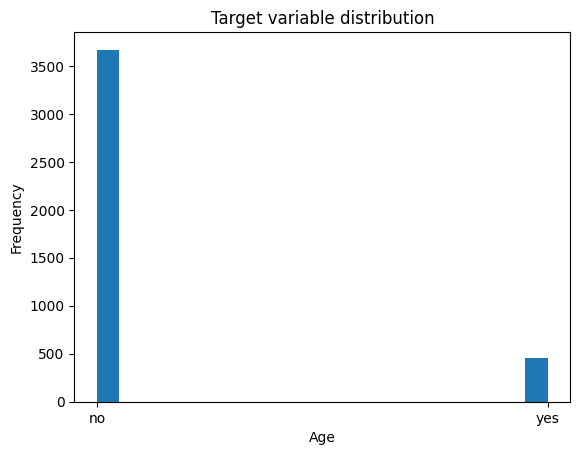

In [6]:
plt.hist(df["y"], bins = 20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Target variable distribution")
plt.show

From this histogram of the target variable, we can already tell there is huge class imbalance. Where the "yes" response has around 500 entries and "no" response has more than 3500 entries.

In [7]:
tokens = ["unknown", "?", "na", "n/a", "none", "null", "", "NaN"]  # list keeps order

token_counts = {}

for col in df.select_dtypes(include=["object", "string"]).columns:
    s = df[col].astype(str).str.strip().str.lower()
    counts = {t: int((s == t).sum()) for t in tokens}
    counts = {t: n for t, n in counts.items() if n > 0}
    if counts:
        token_counts[col] = counts

token_counts

{'job': {'unknown': 39},
 'marital': {'unknown': 11},
 'education': {'unknown': 167},
 'default': {'unknown': 803},
 'housing': {'unknown': 105},
 'loan': {'unknown': 105}}

From this line of code, we can see that there are in fact missing values. After checking for different common "missing-value tokens", the only one introduced was unknown. It showed that variable default is the on with the most missing values: 803. Then, education, housing and loan variables depict similar counts of missing values (around 100), and for job and marital the missingness stays below 50.

Let's inspect now the distribution of some of the "interesting" numerical variables we saw on the df.describe() line of code and some for the categorical variables.

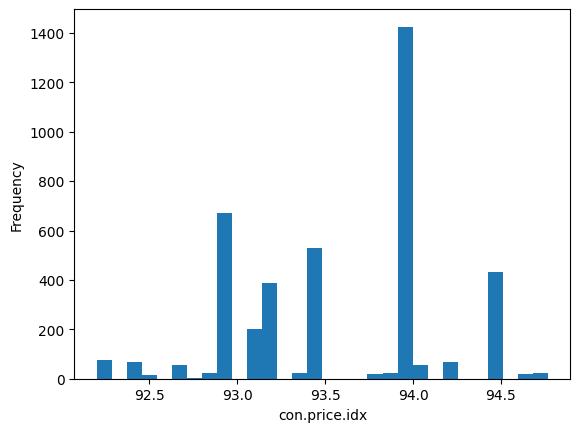

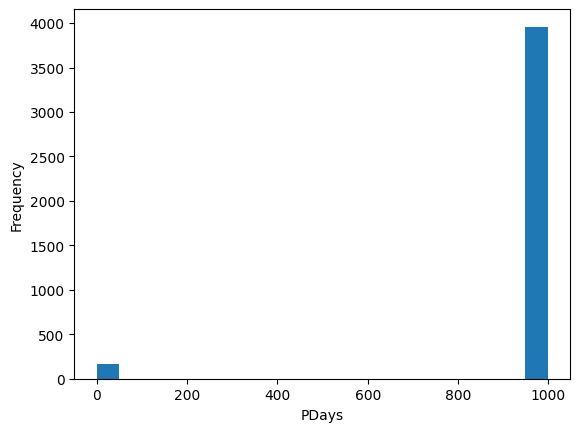

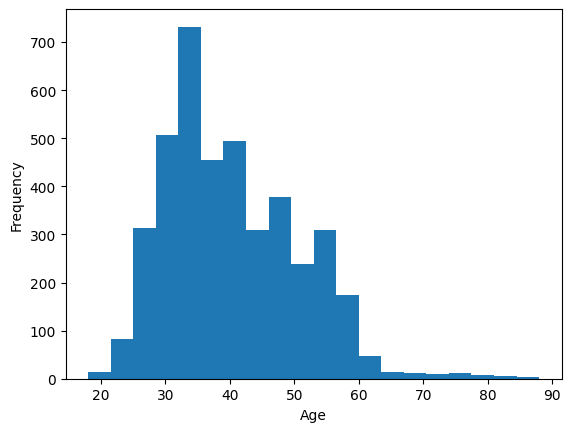

In [8]:
plt.hist(df["cons.price.idx"], bins = 30)
plt.xlabel("con.price.idx")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["pdays"], bins = 20)
plt.xlabel("PDays")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["age"], bins = 20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

These histograms for numerical variables, give us valuable information of the distribution of the variables. First, cons.price.idx shows a "weird" behavior, with a huge spike at 94 and the other frequencies remain somewhat low in comparison. For pdays, we can see great imbalance, where the only values shown go from either 0 to around 50, and from 950 to 1000. With a huge difference from the count of the first compared to the latter range. Finally, age shows a more normal distribution with a slight skewness to the right. The histogram shows that most of the respondents lie in the 25 to 48 group (approximately)

Let's now inspect for the categorical variables

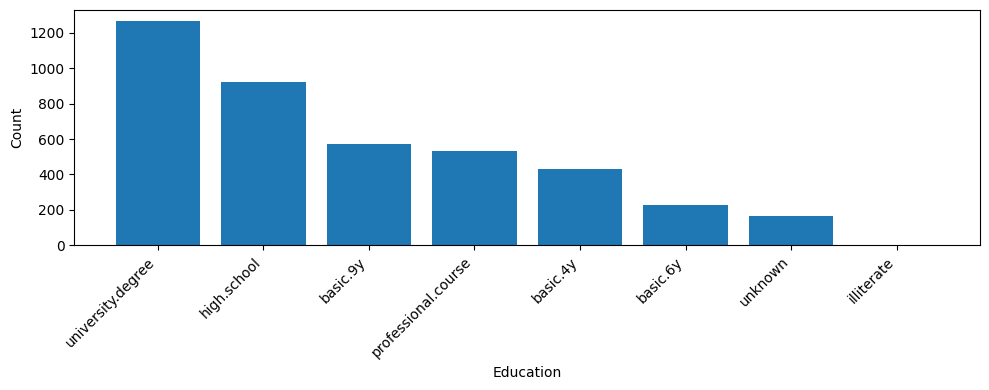

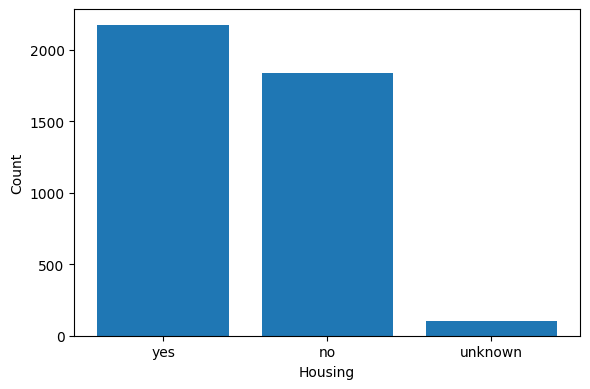

In [9]:
counts = df["education"].value_counts()

plt.figure(figsize=(10,4))
plt.bar(counts.index, counts.values)
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

counts = df["housing"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xlabel("Housing")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

For the education variable, we can see most of the respondents lie on the university degree category and high school. There are very few illiterate respondents. For the housing feature, it seems to be somewhat balanced with most of the observations lying on the "yes" response.

From this and the past stated information, we can identify 2 variables to have special consideration before modelling. pdays and duration.

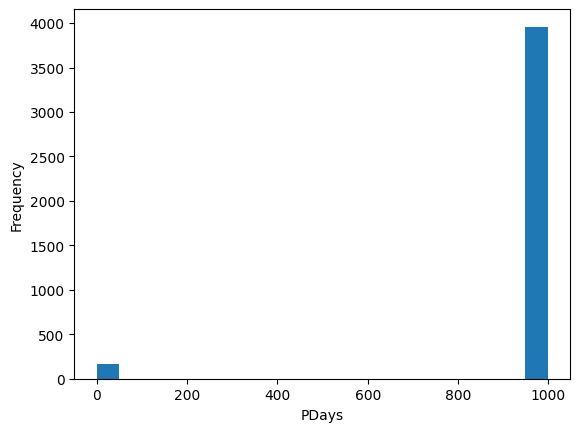

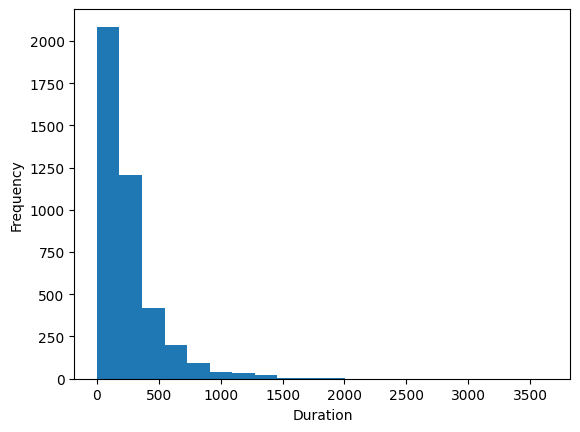

In [10]:
plt.hist(df["pdays"], bins = 20)
plt.xlabel("PDays")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["duration"], bins = 20)
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

Pdays requires special handling because it is extremely skewed. It refers to "days since last contact in a previous campaign". Most values are 999, which translates to "never previously contacted". This creates huge skewness on the data. treating 999 as an actual number may distort the distribution and mislead the model. A reasonable approach would be to replace 999 with NaN or create a binary feature such as "previously_contacted", where if the value is different from 999 the observation would be now "yes" and if not then the observation would be marked as "no".

On the other hand, duration feature also requires special consideration because it can cause data leakage. The goal for this model is to decide "who to call", but call duration is only known after the call has occurred. Including it as a feature may make the model look unrealistically "good", as longer calls usually correlate to success, but it probably won't work in real deployment. Therefore, we should exclude this variable for a pre-call model.

I will now change the pdays variable so that 999 actually represents something. I will create a new feature called "contacted" where if the value for the observation is 999, then in this new feature it will be marked as yes. Otherwise, it will be marked as "no". I do this because 999 isn't a real number of days in this dataset. 999 is a special code meaning "never previously contacted". If we do not change this, we will have extreme skewness, where the distribution is dominated by 999. Also, the model will misinterpret the value. Logistic regression will treat 999 as a large amount of days since last contact. Which would imply the client was contacted a long time ago, which is not true. Note that I do this before splitting because the variable is not "learning" anything from the dataset. It is not fitting or averaging anything. It is just a fixed meaning

It is important to know that I didn't create another feature referring to the actual days since previously contacted for those who did not have 999 because the extent of missingness for that variable would be too high. From the histogram before, we already knew that the extent of values different from 999 was very low (below 5%). Adding this new column would have 96% of NaNs and around 4% of non-missing values.

In [19]:
df["contacted"] = np.where(df["pdays"] == 999, "no", "yes")\

df = df.drop(columns=["pdays",])

3. Splitting the data

In [55]:
y = df["y"]
x = df.drop(columns=["y"])

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, random_state=42,
    stratify = y
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42,
    stratify = y_temp
)

I split the data into 70/15/15 (train, validation and test) in order to maximize the training data size while still reserving enough to validate for model selection. And a final untouched test set for unbiased evaluation

I used stratifies sampling on y because the target is very imbalanced. Stratification will preserve the class proportions across splits. This way, I can prevent misleading evaluation due to an unusually low or high number of negatives or positives in validation or test set.

Splitting must be done before imputation, encoding, scaling and resampling. If we were to perform these steps before splitting, information would be leaked from validation or test into training. For imputation (for example), if we were to fill missing values using statistics computed on the full dataset, then the training set will be using information from the validation and test set. Or if we were to scale before splitting, the training features will be transformed using the mean, standard deviation, minimum and maximum of validation and test set too. Creating data leakage.

4. Missing values

In [56]:
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

token = "unknown"

cat_cols = df.select_dtypes(include=["object", "string"]).columns

unknown_count = df[cat_cols].apply(
    lambda s: s.astype(str).str.strip().str.lower().eq(token).sum()
)

unknown_pct = (unknown_count / len(df) * 100).round(2)

missing_summary2 = missing_summary.join(pd.DataFrame({
    "unknown_count": unknown_count,
    "unknown_pct": unknown_pct
}), how="left").fillna(0)

missing_summary2.sort_values(["missing_count", "unknown_count"], ascending=False)

,missing_count,missing_pct,unknown_count,unknown_pct
default,0,0.0,803.0,19.50
education,0,0.0,167.0,4.05
loan,0,0.0,105.0,2.55
housing,0,0.0,105.0,2.55
job,0,0.0,39.0,0.95
marital,0,0.0,11.0,0.27
age,0,0.0,0.0,0.00
campaign,0,0.0,0.0,0.00
y,0,0.0,0.0,0.00
nr.employed,0,0.0,0.0,0.00


Taking information from point 2 (Data exploration), we can see that the only missing value "token" was "unknown". There are no explicit missing values (NaN) in the whole dataset.

In contrast, variable default has 19.5% of implicit missing values (unknown), education has 4.05% and both loan and housing have 2.55%. Other variables have either 0 or less than 1%.

Based on the table, I will manage missing values in 2 ways, imputation and maintaining "unknown" and treating it as a deparate category for 1 feature only.

I will impute the values with the mode for the following categories: education, loan, housing, job, and marital. Mainly because imputing the values will not distort with the distribution as their extent is very low (>5%). These values are likely missing at random, and they will add unnecessary noise to the model without providing any relevant information.

For feature default, I will treat "unknown" as a separate category. Default variable refers to if a person has credit in default. being financial data, it likely means that there is a lack of credit history or a refusal to disclose. Which could provide valuable information to the model. Also, given that the extent of missingness is almost 20% (almost 1/5 of the observation) it likely means there are highly predictive signals on these "unknown" responses

In [57]:
cols_to_impute = ["education", "loan","housing","job","marital"]
cols_to_keep = ["default"]

for dataset in [x_train, x_val, x_test]:
    dataset.replace('unknown', np.nan, inplace=True)

mode_imputer = SimpleImputer(strategy = "most_frequent")

mode_imputer.fit(x_train[cols_to_impute])

x_train[cols_to_impute] = mode_imputer.transform(x_train[cols_to_impute])
x_val[cols_to_impute] = mode_imputer.transform(x_val[cols_to_impute])
x_test[cols_to_impute] = mode_imputer.transform(x_test[cols_to_impute])


We only perform the model_imputer.fit() operation on the x_train because this way we prevent data leakage. If we fit on the whole dataset, the imputer will see the distribution of the future data. If the most common eduction level in the test set is different from the training set, the imputer would have be influenced by information it shouldn't have access to. We also only fit on the train set because this way we ensure that the model is evaluated on how well it handles data using the same logic it was trained with. If I were to use a different Mode for the test set, I would be introducing a mismatch between the training and test sets.

5. Encode categorical variables

Before encoding, it is important to mention what encoding strategy we are going to work with. Especially since the model will handle logistic regression. Logistic regression assumes a linear relationship between the input features and the log-odds of the target. If categories are encoded poorly, we might force the model to assume a mathematical relationship that does not really exist.

For this dataset, there are a total of 12 categorical features where only 1 is considered ordinal: education. As different educational levels do have a meaningful order. The other 11 can be considered strictly nominal.

Note that the dataset has 1 more variable than at the beginning since we added the categorical variable "contacted" to handle a rare case.

Knowing this, we will perform 3 different types of encoding, ordinal encoding and One-hot encoding. The latter for the 11  categories that are not nominal. And label encoding for the target variable "y", which just refers to 0 or 1, since it is a binary feature.



In [58]:
edu_order = ["illiterate","basic.4y","basic.6y","basic.9y","high.school","professional.course","university.degree"]

ord_encoder = OrdinalEncoder(categories=[edu_order])

x_train['education'] = ord_encoder.fit_transform(x_train[['education']].astype(str))
x_val['education'] = ord_encoder.transform(x_val[['education']].astype(str))
x_test['education'] = ord_encoder.transform(x_test[['education']].astype(str))

nom_cols= ["job","marital","default","housing","loan","contact","month","day_of_week","poutcome","contacted"]
ohe = OneHotEncoder(drop = "first", sparse_output=False).set_output(transform="pandas")
ohe.fit(x_train[nom_cols])

def encode_nominal(df,encoder,cols):
    transformed = encoder.fit_transform(df[cols])
    return pd.concat([df.drop(columns=cols), transformed], axis=1)

x_train_final = encode_nominal(x_train,ohe,nom_cols)
x_val_final = encode_nominal(x_val,ohe,nom_cols)
x_test_final = encode_nominal(x_test,ohe,nom_cols)


label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)


Notice how we fit the encoders on the training set only, then we use .transform on both the validation and test sets. We do this in order to prevent data leakage. If our test set contains a category that is not present in the training set, fitting the whole dataset would leak that piece of information from the test set into the training process, violating the principle of testing on unseen data. We also fit only on the train in order to maintain consistency. The fitting process learns the mapping of the variables (e.g., Housing = [1,0]). If we now fit separately on the test set, the model might learn that Housing = [0,1], making completely inaccurate.

Let's depict the data to observe dimensionality changes.


In [59]:
x_train_final.head()

,age,education,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,contacted_yes
1948,49,5.0,128,8,0,1.4,93.444,-36.1,4.966,5228.1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2198,44,1.0,170,2,0,1.4,93.918,-42.7,4.963,5228.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
166,32,6.0,374,2,0,-1.8,92.893,-46.2,1.313,5099.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2152,44,3.0,182,1,0,-0.1,93.200,-42.0,4.153,5195.8,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2881,33,4.0,399,1,0,-1.8,92.893,-46.2,1.344,5099.1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [60]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contacted
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no,no


We can observe that the dataset went from having 21 columns or features to having 43. This is due to One-hot encoding. For example, job, having 10 categories has now 20 features referring to this variable. Increasing the size by 10. And this is similar for other variables. For ordinal encoding, the dimensionality is maintained, so education was not stretched as some of the nominal variables.

Moving to the interpretability of the coefficients, they become very interpretable, especially in One-hot encoding. Each coefficient represents the change in log-odds compared to the dropped reference category. For the ordinal feature, the coefficient represents the impact of "moving up" a level in education.

Finally, about the decision boundaries, logistic regression create a linear decision boundary. By splitting the features using One-hot encoding, we allow the model to represent individual "changes". The model can assign different weights to each category, allowing the "linear" plane to effectively jump to different levels for different categories.

6. Feature scaling

I will scale the numeric features, which are: age, duration, campaign, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, and nr.employed. I will use standardization for this, which transforms data to have a mean 0 and standard deviation of 1. This form of scaling can be done since Logistic regression uses the sigmoid function to map numbers into probabilities. If for example, nr.employed has a value of 5200, it will be much larger for a feature like emp.var.rate with a value of 1.1, the model will struggle to find optimal weights. Standardization ensure that all values are evaluated using the same scale, so that huge values don't dominate the loss function just because of the scale in which the "swim" in.

In [61]:
num_cols = ["age","duration","campaign","previous","emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]

scaler = StandardScaler()

scaler.fit(x_train_final[num_cols])

x_train_final[num_cols] = scaler.transform(x_train_final[num_cols])
x_val_final[num_cols] = scaler.transform(x_val_final[num_cols])
x_test_final[num_cols] = scaler.transform(x_test_final[num_cols])

x_train_final[num_cols].head()


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
1948,0.849392,-0.492397,2.080561,-0.357112,0.848208,-0.233416,0.937292,0.779757,0.842054
2198,0.366946,-0.331261,-0.209287,-0.357112,0.848208,0.576339,-0.488655,0.778029,0.842054
166,-0.790923,0.451399,-0.209287,-0.357112,-1.197978,-1.174714,-1.244839,-1.324662,-0.900585
2152,0.366946,-0.285222,-0.590929,-0.357112,-0.110942,-0.650252,-0.337418,0.311404,0.405719
2881,-0.694434,0.547314,-0.590929,-0.357112,-1.197978,-1.174714,-1.244839,-1.306804,-0.900585


Notice how I fitted the scaler on the training set only. This is because fitting involves calculating both the mean and standard deviation. If I were to include the validation or test sets in this calculation, I would be "leaking" future information into the training process. This form of data leakage leads to overly optimistic performance estimates.

When it comes to the mathematical impact of standardization, we need to analyze this from three points:

1. Gradient based optimization

Logistic regression uses solvers which rely on gradient descent principles. If scaling was not done, the cost function can be extremely elongated and have an eliptical structure. This would cause the gradient to oscillate and take much longer to reach a global minimum. Scaling allows the cost function to be more spherical, which leads to faster convergence and better stability.

2. Magnitude and comparability of coefficients

If scaling was not performed, the coefficients would not be comparable. Age (for example), has a coefficient that can not be compared with "euribor3m" since their units are different, one is in years and the latter is an interest rate. but since I scaled the features, coefficients become standardized weights. All features now have a standard deviation of 1, and we can directly compare the magnitudes. If the coefficient for "euribor3m" is now 1.5 and age is 0.6, we can confidently state that "euribor3m" has a stronger relative impact on prediction.

3. Interpretation of regularization penalties

Regularization adds a penalty term to the cost function based on the size of the coefficients. If features were not scaled, the model will naturally assign smaller coefficients to variables with larger ranges and larger coefficients to small-range variables. Regularization would eeffectively ignore features with larger scales and over-penalize those with smaller scales. But since we scaled, we ensured that the regularization penalty is applied fairly across all features.

7. Feature selection

<Axes: >

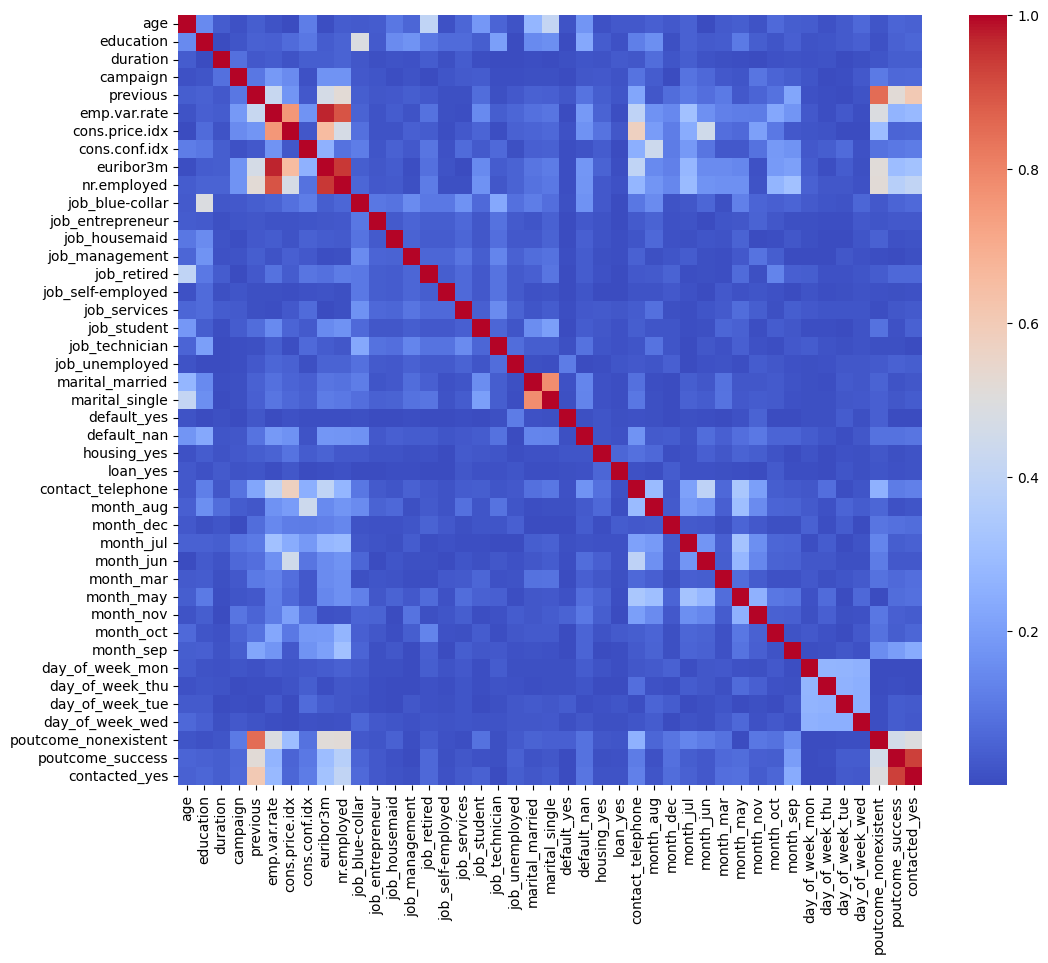

In [64]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(x_train_final)

corr_matrix = x_train_final.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')

The plot shows the features with the most variance. While we can not easily tell which variables to remove, the correlation matrix shows us in which direction we should move.

Next, we will remove features with low variance, which are essentially constants. They don't provide enough contrast for Logistic regression to learn a meaningful weight. Since we performed One-hot encoding to many categorical variables, we will use the variance formula for the Bernoulli distribution. The threshold we will choose is 0.01. this means that if a category appears in 99% of the rows the computer will interpret it as the feature not having enough "contrast" to help the model distinguish between a yes and a no subscription. We used this threshold because in the context of Logistic regression, the model needs the feature x to vary so it can calculate how much the variation affects the probability of y. If a feature doesn't have enough variance it will be removed.

In [65]:
features_to_keep = x_train_final.columns[selector.get_support()]

x_train_fs = x_train_final[features_to_keep]
x_val_fs = x_val_final[features_to_keep]
x_test_fs = x_test_final[features_to_keep]

print(f"Removed {x_train_final.shape[1] - x_train_fs.shape[1]} low-variance features.")

Removed 2 low-variance features.


We removed 2 features with very low variance. Next we will remove feature with high correlation.

I will choose a correlation threshold of 0.9, because I want to have a balance between preserving information and ensure mathematical stability. 0.9 is a very common threshold to use as well. I also want to mitigate multicollinearity. In linear models like Logistic regression, highly correlated predictors result in a badly conditioned covariance matrix, which leads to high variance in coefficient estimates. The instability of coefficients will undermine the interpretability of the model weights and can hinder the convergence of gradient-based solvers. By removing features above the 0.9 threshold, we ensure more reliable and stable parameter estimation without losing significant predictive information.

In [66]:

corr_matrix = x_train_fs.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

x_train_fs = x_train_fs.drop(columns=to_drop)
x_val_fs = x_val_fs.drop(columns=to_drop)
x_test_fs = x_test_fs.drop(columns=to_drop)

print(f"Dropped due to high correlation: {to_drop}")

Dropped due to high correlation: ['euribor3m', 'nr.employed', 'contacted_yes']


As seen, we removed 3 variables with high correlation. Now, we need to discuss an important question: should we remove any feature?

The answer to this question is, yes, we should. The column to be removed is duration. In past explanations I have stated that duration can be a severe trigger for data leakage, and at this step we will remove it. Duration is only known after the call ends. If duration is greater than 0, the person picked up. If the duration is very long, the person was likely already subscribing. If I were to keep duration, the model would yield 99% accuracy, which is completely useless in the real world because we won't know the duration of the call before it is made. Remember that the question we are trying to answer is, will this person subscribe?

In [67]:
x_train_fs = x_train_fs.drop(columns = ["duration"])
x_val_fs = x_val_fs.drop(columns = ["duration"])
x_test_fs = x_test_fs.drop(columns = ["duration"])

It is important to remind that feature selection was only done on the training set. We do this in order to avoid "peeking" and for stability reasons. If I were to use the test set to decide whether a feature is important or correlated, the feature selection would be biased by data the model isn't supposed to know. Additionally, if we were to perform feature selection on the entire dataset, we would be overfitting. We might find a correlation that only exists because of a few outliers in the test set. Performing this step on the training set ensures the selection of variables is robust enough to generalize on new, unseen data.

Another relevant thing to mention is that we perform this step after scaling because the variance is sensitive to the scale in which the numbers are in. Since we already standardized the numeric features, every feature's variance is now comparable, making the 0.01 threshold actually meaningful.

8. Adressing class imbalance

We are going to first quantify the distribution, we need to prove there is class imbalance before addressing the actual problem.

In [68]:
print(pd.Series(y_train).value_counts(normalize=True))

0    0.890392
1    0.109608
Name: proportion, dtype: float64


We see that 89% of the results are "no" and only 11% are yes. So yes, there is class imbalance, and we need to address this issue. This is a problem because the cost of "missing" a potential subscriber is much higher than the cost of a wasted phone call. If we didn't do anything about it, the model could simply predict "no" for every single person and achieve 89% accuracy, while being completely useless at finding actual customers.

The resampling technique to be used is SMOTE. I chose this technique over Random oversampling to provide a more robust representation of the minority class. SMOTE creates synthetic "subscriber" instances rather than simple duplicates. We placed this at this stage of the pipeline because the resampling step is performed strictly on the training set after splitting, encoding, and scaling. This way we prevent data leakage: if SMOTE was applied before the split, the training set would be allowed to "see" information from the test via synthetic neighbors, leading to artificially inflated performance. In addition, performing SMOTE at this step makes it so that the test and validation sets remain imbalanced to reflect a real-world distribution. Finally, since SMOTE relies on k-nearest neighbors, it must follow standardization so that the feature distances are calculated on a comparable scale.

On another note, when talking about the assumptions and model impact, SMOTE is the right choice because it assumes the minority class exist in continuous clusters in the feature space. It uses linear interpolation between existing minority sample to fill in gaps, assuming the space between two "yes" instances is also a "yes".

Its effect on logistic regression is very beneficial for the model because Logistic regression naturally biases its decision boundary towards the majority class. By applying SMOTE, we are effectively forcing the algorithm to prioritize the minority class. Also, during optimization, a balanced dataset ensures that gradient updates are influences equally by both classes, preventing the majority class from dominating the learning signal. To end with, SMOTE prevents the model from memorizing the minority class instances (overfitting), which is risky with simple random oversampling.

In [70]:
smote = SMOTE(random_state=42)

x_train_res, y_train_res = smote.fit_resample(x_train_fs, y_train)

print(f"Original training shape: {x_train_fs.shape}")
print(f"Resampled training shape: {x_train_res.shape}")

Original training shape: (2883, 37)
Resampled training shape: (5134, 37)


In [71]:
print("Resampled Class Distribution:")
print(pd.Series(y_train_res).value_counts(normalize=True))

Resampled Class Distribution:
0    0.5
1    0.5
Name: proportion, dtype: float64


We must apply resampling only to the training set, validation and test sets should not be touched. This is due to the fact that the validation and test sets must remain "mirror" of the reality. Balancing the test set, would lead to testing the model on a fake world, where 50% of the people subscribe. Giving the model and us a false sense of security, as we want to see how the model performs against the real 11% subscription rate (in this case).

9. Training a Logistic regression model

In [73]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(x_train_res, y_train_res)

y_val_pred = log_reg.predict(x_val_fs)

acc = accuracy_score(y_val,y_val_pred)
prec = precision_score(y_val,y_val_pred)
rec = recall_score(y_val,y_val_pred)

print("Validation metrics")
print()
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")

Validation metrics

Accuracy: 0.8090614886731392
Precision: 0.32142857142857145
Recall: 0.6617647058823529


In [74]:
zero_rule_acc = (y_val == 0).mean()
print(f"Zero Rule Accuracy: {zero_rule_acc:.4f}")

Zero Rule Accuracy: 0.8900


The model achieved an accuracy of ~81 while the Zero Rule baseline sits at 89%. Af first it may seem that the model actually performed worse than the baseline on accuracy terms. However, since we had an imbalanced dataset where SMOTE was applied, this was a great result. The zero rule has a 0% recall (Accuracy trap), meaning it identifies zero actual subscribers, making it useless for a marketing campaign.

By applying SMOTE during training, we shifted the model's decision boundary to give more weight to the minority class. As a result, we traded a small drop in accuracy (8%) in order to gain major practical utility. Having 66% recall means the model successfully identified two thirds of all potential subscribers, proving that the preprocessing pipeline is mathematically sound and aligned with the business objective.

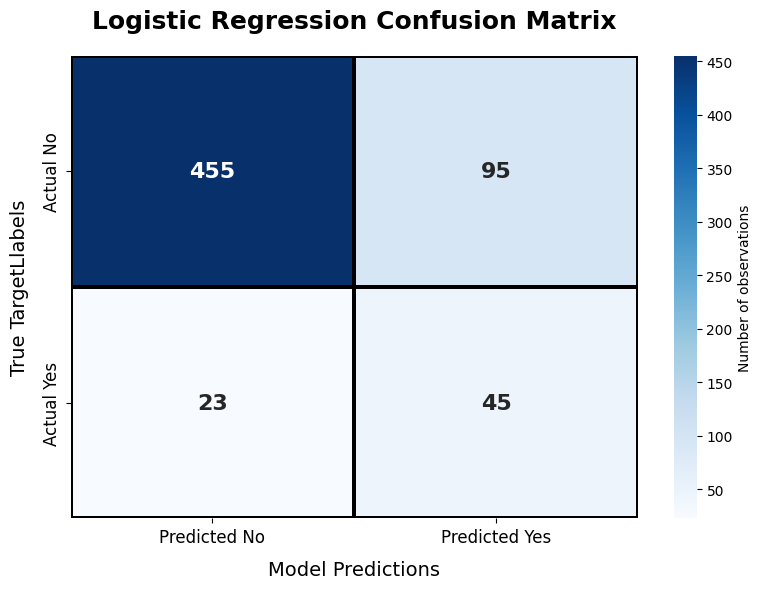

In [75]:
conf_mat = confusion_matrix(y_val,y_val_pred)

plt.figure(figsize=(8, 6))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
                 linewidths=1.5, linecolor="black", annot_kws={"size": 16, "weight": "bold"},
                 cbar_kws={"label": "Number of observations"})

ax.set_xticklabels(["Predicted No", "Predicted Yes"], fontsize = 12)
ax.set_yticklabels(["Actual No", "Actual Yes"], fontsize = 12)

plt.title("Logistic Regression Confusion Matrix", fontsize = 18, fontweight="bold", pad=20)
plt.xlabel("Model Predictions", fontsize = 14, labelpad=10)
plt.ylabel("True TargetLlabels", fontsize = 14, labelpad=10)

plt.tight_layout()
plt.show()